### MNIST
- MNIST は、「0」~「9」の手書き数字の画像データセット。
- Yann LeCunらによって、手書き文字データセットの NIST データベースから抽出＆加工して、機械学習のチュートリアル用に作成されて公開されている。
- 画像データを説明変数 (X)、ラベルを目的変数 (y) として、多クラス分類問題として、学習モデルを作成する。
- MNISTは、sklearn のサンプルデータセットに含まれています。


画像データ (70000, 784)
ラベル (70000,)
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 

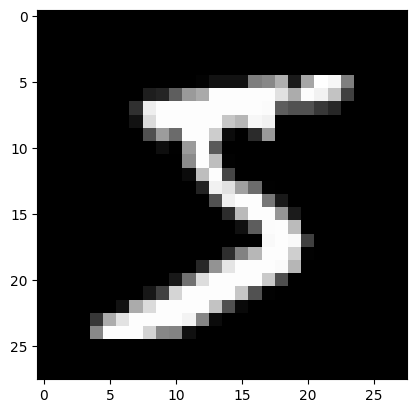

In [4]:
# MNISTデータのダウンロード

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False) 

print('画像データ', mnist.data.shape)
print('ラベル', mnist.target.shape)

# 画像データは784次元のベクトルで表されているので、28x28の行列に変換して表示する
d = mnist.data[0].reshape([28,28]) # 28x28の行列に変換
for y in range(28): # 28行をループ
    for x in range(28): # 28列をループ
        print(f'{int(d[y,x]):3d}', end=' ') # 画素値を3桁で表示し、スペースで区切る
    print()


plt.imshow(mnist.data[0].reshape(28,28), cmap=plt.cm.gray)
plt.show()


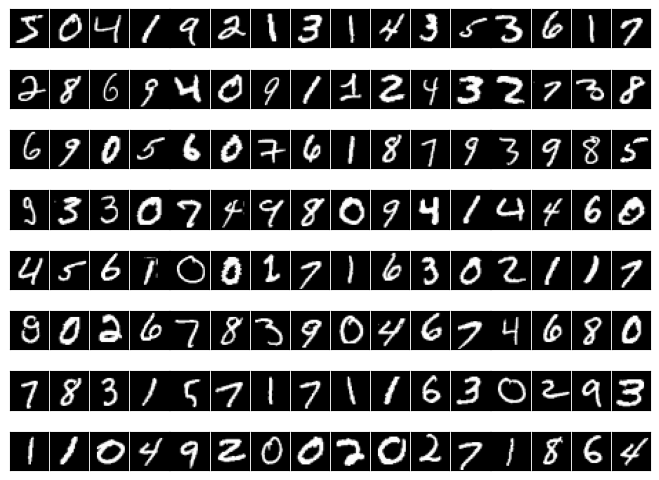

In [ ]:
# MNISTデータの画像表示

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False) 

W = 16 # 横に並べる個数
H = 8 # 縦に並べる個数
fig = plt.figure()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1.0, hspace=0.05, wspace=0.05) # サブプロットの余白を調整
for i in range(W*H): # W*H個のサブプロットを作成
    ax = fig.add_subplot(H, W, i + 1, xticks=[], yticks=[]) # サブプロットを追加し、軸の目盛りを消す
    ax.imshow(mnist.data[i].reshape((28, 28)), cmap=plt.cm.gray) # 画像データを28x28の行列に変換して表示
plt.show()

### 画像データの分析
画像データ(768次元)を２次元に次元削減して、手書き文字の分布状況をみる。

T-SNEで二次元に削減する。また、2000枚程度に減らしてから処理する。

>**T-SNE（t-distributed Stochastic Neighbor Embedding）**
>- 高次元データを低次元（通常は2次元または3次元）にマッピングするための機械学習アルゴリズム。
>- データの類似性を保ちながら、データポイント間の距離を低次元空間で表現する。
>- つまり、似ているデータは近くに、異なるデータは遠くに配置される。

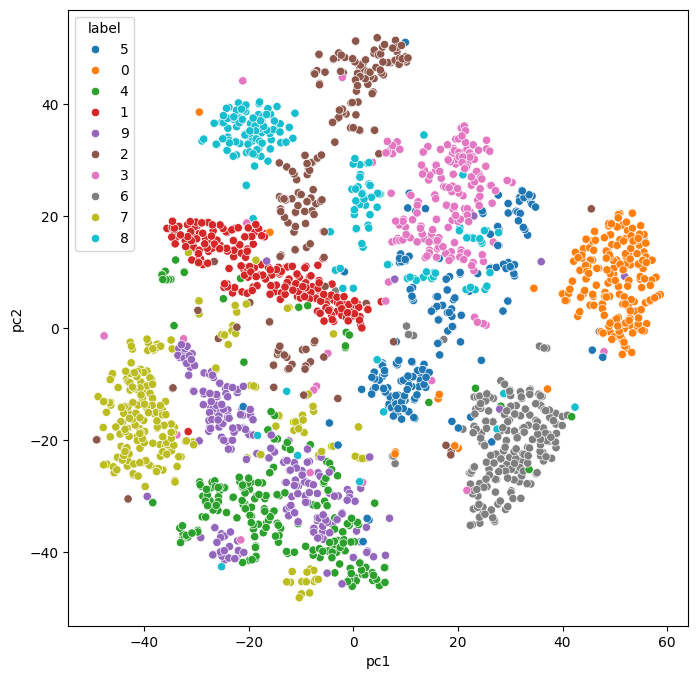

In [ ]:
# T-SNEによる次元削減と可視化

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False)

tsne = TSNE(n_components=2, random_state=0) # T-SNEのインスタンスを作成
tsne = tsne.fit_transform(mnist.data[:2000]) # 最初の2000個のデータを使って次元削減

df = pd.concat([
    pd.DataFrame(tsne, columns=['pc1', 'pc2']), # T-SNEの結果をデータフレームに変換
    pd.DataFrame(mnist.target[:2000], columns=['label'])], axis=1) # ラベルをデータフレームに変換して結合
plt.figure(figsize=(8, 8)) # 図のサイズを指定
sns.scatterplot(data=df, x='pc1', y='pc2', hue='label') # T-SNEの結果を散布図で表示し、ラベルごとに色分け
plt.show()



### 訓練データの準備

MNISTの学習モデルを構築するときは、機械学習では、28x28のグレースケールの画像を784次元の多次元データとして扱う。

まず、0〜255のグレースケール画像の値を 0.0〜1.0の範囲に正規化 しておく

In [10]:
# 訓練データの準備

from sklearn.datasets import fetch_openml

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False)

X = mnist.data.reshape(70000, 784) / 255  # [0,1]で正規化
y = mnist.target.astype(int) # ラベルを整数型に変換

from sklearn.model_selection import train_test_split # 訓練データとテストデータに分割

# stratify=mnist.targetを指定することで、訓練データとテストデータのクラス分布が元のデータセットと同じになるように分割される
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=0, stratify=mnist.target) 

print('訓練データ数:', len(X_train))
print('テストデータ数:', len(X_test))



# MEMO:stratifyについて
# stratifyは、train_test_split関数でデータを分割する際に、指定したラベルの分布を保つための引数。
# 例えば、クラス分類の問題で、あるクラスが全体のデータセットの10%を占めている場合、
# stratifyを指定することで、訓練データとテストデータの両方にそのクラスが10%ずつ含まれるように分割される。
# このことを、層化抽出(比例配分)などとも呼ぶ。
# これにより、モデルの評価がより正確になります。
# 「層化」とも呼ばれる。


訓練データ数: 60000
テストデータ数: 10000


### 多層パーセプトロン
MNISTは、簡単に線形分離できなさそうなので、例としてニューラルネットワークの一種である多層パーセプトロン(MLPClassifier)を使って分類モデルを作る。

`sklearn` モジュールから、`MLPClassifier`をインポートして使う。

#### ハイパーパラメータ
MLPClassifier は、scikit-learnライブラリの中にある多層パーセプトロン (MLP: Multi-layer Perceptron) を用いた分類器。

以下に、主要なハイパーパラメータとその解説を示す。

1. hidden_layer_sizes: `tuple, default=(100,)`
    - 隠れ層のサイズを指定する。例えば、(100,)は1つの隠れ層に100ユニットを持つことを意味する。
    - 複数の隠れ層を持たせたい場合は、(100, 50)のように指定する。
2. activation: `{'identity', 'logistic', 'tanh', 'relu'}, default='relu'`
    - 各隠れ層の活性化関数を指定する。
        - `'identity':` 恒等関数
            -  $ f(x)=x $
        - `'logistic':` シグモイド関数
            - $ f(x)=\frac{1}{1+e^{-x}} $
        - `'tanh':` 双曲線正接関数
            - $ f(x)=tanh(x) $
        - `'relu':` 修正線形単位(ランプ関数)
            - $ f(x)=max(0,x) $
3. solver: `{'lbfgs', 'sgd', 'adam'}, default='adam'`
    - 重みの最適化に用いるアルゴリズムを指定する。
        - `'lbfgs'`: 拡張ベイズ法（準ニュートン法）
        - `'sgd'`: 確率的勾配降下法
        - `'adam'`: アダム（適応的モーメント推定法）
4. learning_rate: `{'constant', 'invscaling', 'adaptive'}, default='constant'`
    - 学習率のスケジュールを指定する。
        - `'constant'`: 固定学習率
        - `'invscaling'`: 初期学習率を徐々に減少させる
        - `'adaptive'`: 以前のエポックでのトレーニング誤差が改善しない場合に学習率を減少させる
5. learning_rate_init: `float, default=0.001`
    - 初期学習率を指定する。
6. max_iter: ` int, default=200`
    - 最大エポック数（反復回数）を指定する。
7. shuffle: `bool, default=True`
    - 各エポックの前にデータをシャッフルするかどうかを指定する。

訓練データ数: 60000
テストデータ数: 10000


c:\Users\44979\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


訓練データに対する正解率: 0.8762333333333333
テストデータに対する正解率: 0.8769


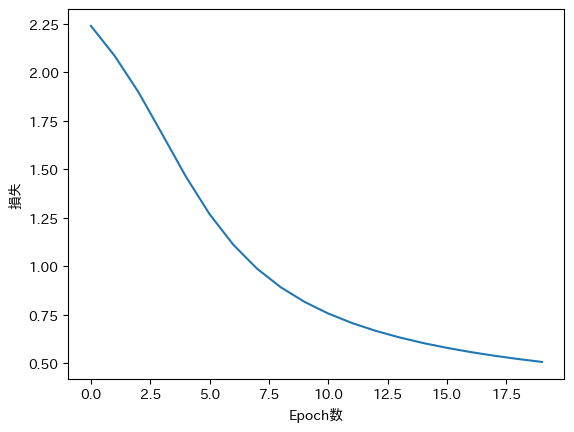

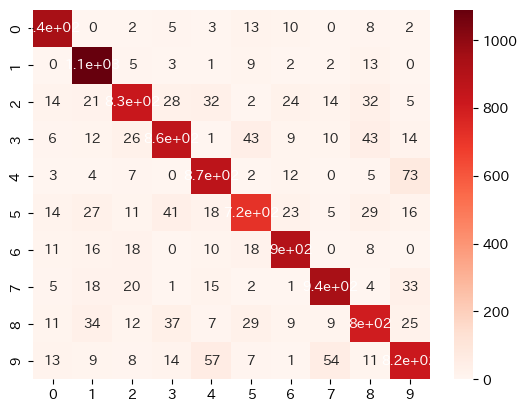

[5 2 6 4 8 2 6 7 3 0]


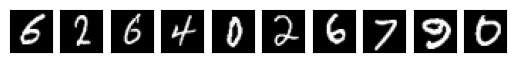

In [ ]:
# ３層パーセプトロンで、活性化関数はシグモイド関数、最適化は確率的勾配降下法を用いて、
# MNISTデータセットの画像認識を行うコード例

from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.metrics import confusion_matrix

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False)

X = mnist.data.reshape(70000, 784) / 255  # [0,1]で正規化
y = mnist.target.astype(int) # ラベルを整数型に変換

from sklearn.model_selection import train_test_split # 訓練データとテストデータに分割

# stratify=mnist.targetを指定することで、訓練データとテストデータのクラス分布が元のデータセットと同じになるように分割される
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=0, stratify=mnist.target) 

print('訓練データ数:', len(X_train))
print('テストデータ数:', len(X_test))


model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='logistic',
    solver='sgd',
    max_iter=20)


log = model.fit(X_train, y_train)

print('訓練データに対する正解率:', model.score(X_train, y_train))
print('テストデータに対する正解率:', model.score(X_test, y_test))

# 警告は、max_iter=20で学習が収束しなかったことを示している。
# 収束させるためには、max_iterの値を増やすか、solverを変更するなどの対策が必要。


# 学習データをグラフで表示する
plt.plot(log.loss_curve_) # 学習の損失関数の値をエポック数に対してプロット
plt.xlabel('Epoch数')
plt.ylabel('損失')
plt.show()

# ニューラルネットワークでは、損失 (loss) が減少しているときは、まだ順調に学習が進んでいることになりますが、過学習の恐れがあります。


# 混同行列を表示する
y_pred = model.predict(X_test) # テストデータに対する予測ラベルを取得
cm = confusion_matrix(y_test, y_pred) # 混同行列を計算
sns.heatmap(cm, annot=True, cmap='Blues') # 混同行列をヒートマップで表示。annot=Trueでセルに数値を表示、cmap='Blues'で青系のカラーマップを使用
plt.show()



# テストデータの最初の10個の画像と予測されたラベルを表示する関数
def plot_mnist(X, y):
    fig = plt.figure()
    for i in range(10):
        ax = fig.add_subplot(1, 10, i + 1, xticks=[], yticks=[])
        ax.imshow(X[i].reshape((28, 28)), cmap=plt.cm.gray)
    print(y[:10])
    plt.show()

plot_mnist(X_test, y_pred) # テストデータの最初の10個の画像と予測されたラベルを表示


### 学習済みモデルの保存

機械学習モデルをAIアプリに組み込むときは、毎回、訓練する必要がないように学習済みモデルだけ、ファイルに保存する。



>pickle とは
>- Pythonでのオブジェクトをシリアライズする一般的な方法。
>   - シリアライズ（直列化） とは、プログラミング言語においてオブジェクトをバイト列のデータに表現に変換すること。
>   - 逆に、デシリアライズ（非直列化）とは、シリアライズしたバイト列から元のオブジェクトに復元すること。

In [42]:
# ３層パーセプトロンで、活性化関数はシグモイド関数、最適化は確率的勾配降下法を用いて、
# MNISTデータセットの画像認識を行うコード例

from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.metrics import confusion_matrix
import pickle

# MNISTデータセットをダウンロード
mnist = fetch_openml('mnist_784', as_frame=False)

X = mnist.data.reshape(70000, 784) / 255  # [0,1]で正規化
y = mnist.target.astype(int) # ラベルを整数型に変換

from sklearn.model_selection import train_test_split # 訓練データとテストデータに分割

# stratify=mnist.targetを指定することで、訓練データとテストデータのクラス分布が元のデータセットと同じになるように分割される
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=0, stratify=mnist.target) 

print('訓練データ数:', len(X_train))
print('テストデータ数:', len(X_test))


model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='logistic',
    solver='sgd',
    max_iter=20)


log = model.fit(X_train, y_train)

print('訓練データに対する正解率:', model.score(X_train, y_train))
print('テストデータに対する正解率:', model.score(X_test, y_test))

# 学習済みモデルをpickleで保存する
with open('./model/mnist-model.pickle', mode='wb') as fp:
    pickle.dump(model, fp)





訓練データ数: 60000
テストデータ数: 10000


c:\Users\44979\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


訓練データに対する正解率: 0.87545
テストデータに対する正解率: 0.8766


### 自分の手書き文字の認識
画像は、Pillow/PIL ライブラリを用いて操作する

サイズ (746, 746)


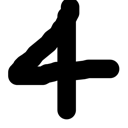

In [27]:

from PIL import Image
im = Image.open("./data/4.png")
print('サイズ', im.size)

#im を小さく表示
im.thumbnail((128, 128))
im

In [47]:
# 画像の前処理とモデルへの入力
from PIL import Image
import numpy as np
import pickle


im = Image.open("./data/4.png").convert('L').resize((28,28)) # 画像をグレースケールに変換してから、28x28にリサイズ
im
myimage = np.array(im).reshape(1,-1) # 画像を28x28の行列から、1x784のベクトルに変換
myimage = (255 - myimage)/255 # 画像の色を反転して、[0,1]で正規化
print('前処理後の画像の形状:', myimage.shape) # 画像の前処理が正しく行われているか確認するために、myimageの形状を表示

# 学習済みモデルをpickleで読み込む
with open('./model/mnist-model.pickle', mode='rb') as fp:
    model = pickle.load(fp)

# 画像をモデルに入力して、予測されたラベルを表示する
predicted_label = model.predict(myimage)[0] # 画像をモデルに入力して、予測されたラベルを取得
print('予測されたラベル:', predicted_label)

前処理後の画像の形状: (1, 784)
予測されたラベル: 4
